<a href="https://colab.research.google.com/github/NishanBhurtel/datamining_Lab/blob/main/datawarehouse_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Consider a dataset of your own choice and perform necessary preprocessing steps
This should cover
a. data cleaning (handling missing values, smoothing noisy data removing duplicates…
b. Data integration
c. Data transformation (normalization, different encoding techniques…)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
data=pd.read_csv("/content/drive/MyDrive/machine learning dataset/Salary Data.csv")
data.sample(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
301,31.0,Male,Bachelor's,Junior Project Manager,3.0,55000.0
330,31.0,Female,Bachelor's,Junior Business Development Associate,3.0,50000.0
271,32.0,Female,Bachelor's,Junior Marketing Manager,4.0,60000.0
47,45.0,Female,Master's,Director of Marketing,16.0,180000.0
132,40.0,Female,Master's,Senior Training Specialist,12.0,100000.0
36,35.0,Female,Bachelor's,HR Generalist,7.0,60000.0
52,40.0,Female,Bachelor's,Event Coordinator,12.0,60000.0
137,30.0,Female,Bachelor's,Junior Marketing Manager,4.0,50000.0
232,27.0,Female,Master's,Junior Research Scientist,1.5,50000.0
319,37.0,Male,Bachelor's,Senior Business Development Manager,10.0,120000.0


In [19]:
data.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [20]:
data.shape

(375, 6)

In [21]:
data.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [22]:
data.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [40]:
data=data.dropna()

In [41]:
data.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


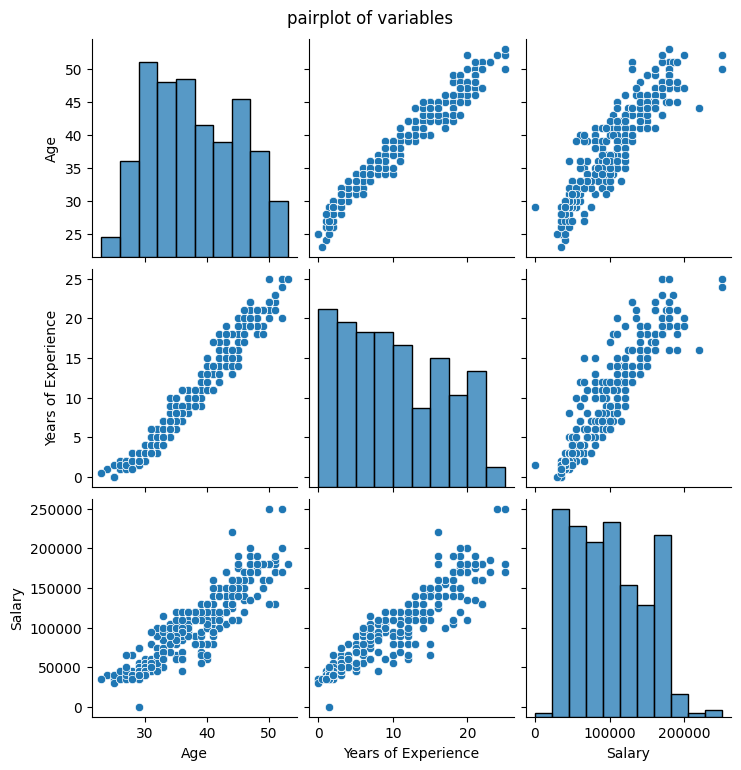

In [42]:
sns.pairplot(data)
plt.suptitle('pairplot of variables',y=1.02)
plt.show()

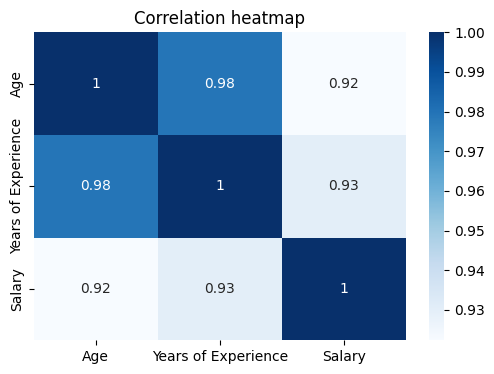

In [43]:
# plotting correlation between each pair of variables.
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='Blues')
plt.title('Correlation heatmap')
plt.show()

In [44]:
# Converts each categorical column into multiple binary (0/1) columns (One Hot Encoding)
data_encoded = pd.get_dummies(data, columns=['Gender', 'Education Level', 'Job Title'], drop_first=True)
print("\nEncoded Columns:\n", data_encoded.columns)


Encoded Columns:
 Index(['Age', 'Years of Experience', 'Salary', 'Gender_Male',
       'Education Level_Master's', 'Education Level_PhD',
       'Job Title_Accountant', 'Job Title_Administrative Assistant',
       'Job Title_Business Analyst', 'Job Title_Business Development Manager',
       ...
       'Job Title_Supply Chain Manager', 'Job Title_Technical Recruiter',
       'Job Title_Technical Support Specialist', 'Job Title_Technical Writer',
       'Job Title_Training Specialist', 'Job Title_UX Designer',
       'Job Title_UX Researcher', 'Job Title_VP of Finance',
       'Job Title_VP of Operations', 'Job Title_Web Developer'],
      dtype='object', length=179)


In [45]:
# Data Preprocessing (removing the rows with missing values (NaN))
data_encoded.dropna(inplace=True)

In [46]:
# Step 7: Feature and Target Selection
X = data_encoded.drop('Salary', axis=1)
y = data_encoded['Salary']

In [47]:
# Step 8: Impute Missing Values in X (if any)with the mean of each column
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)